In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
import torch
import PINN
from PINN import reader, models, pl, tl

import matplotlib.pyplot as plt

In [3]:
from TorchDiffEqPack import odesolve

In [4]:
os.chdir("../../")

In [5]:
# CHANG THIS !!!!!
ckpt_path = "logs/tom_pos-DM_EigenVectors_multiBnch/MLP_full_tsense/lightning_logs/version_0/checkpoints/epoch=126-total_loss=0.00003808.ckpt"


# load data

In [6]:
# MODEL CLASS and define model
model_class = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_class}")
mlp_model = model_class.load_from_checkpoint(ckpt_path)
device = mlp_model.device

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


In [7]:

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

n_timepoint = 7
n_dimension =10

# the DS
DS_t7 = reader.HigDim_AnnDS(AnnData=adata, n_timepoint=n_timepoint,  
                            n_dimension = n_dimension,
                              cellstate_key="DM_EigenVectors",  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False)


t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b.cpu().numpy().reshape(n_timepoint, -1)

s_all = DS_t7.s.float().requires_grad_()
t_b = DS_t7.t_b.float().requires_grad_()
cellstate = torch.from_numpy(DS_t7.cellstate).float().requires_grad_()

In [8]:
cellstate = torch.from_numpy(DS_t7.cellstate).float()

In [9]:
cellstate.min(axis=0), cellstate.max(axis=0)

(torch.return_types.min(
 values=tensor([-0.0028, -0.0024, -0.0090, -0.0085, -0.0030, -0.0073, -0.0086, -0.0055,
         -0.0033, -0.0085]),
 indices=tensor([20046, 23737, 23344, 20046,   161, 11067, 23344,   345, 25430, 11907])),
 torch.return_types.max(
 values=tensor([-0.0028,  0.0034,  0.0027,  0.0062,  0.0081,  0.0043,  0.0058,  0.0097,
          0.0165,  0.0062]),
 indices=tensor([ 3681,  3681, 20046,  3199, 11169, 23344, 20046, 20046, 14348, 25166])))

In [10]:
adata.obsm['DM_EigenVectors'].shape

(49390, 30)

In [11]:
t7_ad.obsm['DM_EigenVectors'].shape

(25948, 30)

# sample input

In [13]:
subset_cb = np.random.choice(t7_ad.obs_names, int(0.2*len(t7_ad.obs_names)), replace=False)
subset_ad = t7_ad[subset_cb].copy()

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [82]:
t7_ad.shape[0], subset_ad.shape[0], sampled_ad.shape[0]

(25948, 4707, 20)

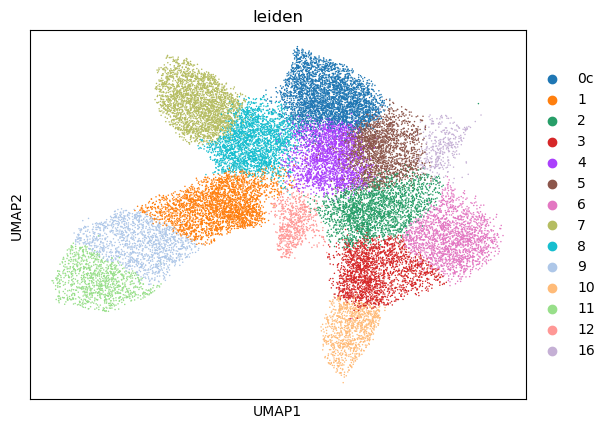

In [190]:
sc.pl.umap(t7_ad, color='leiden')

In [193]:
sampled_cbs = np.random.choice(t7_ad.obs.query("`leiden` == '0c'").index, 10)
sampled_ad = t7_ad[sampled_cbs].copy()

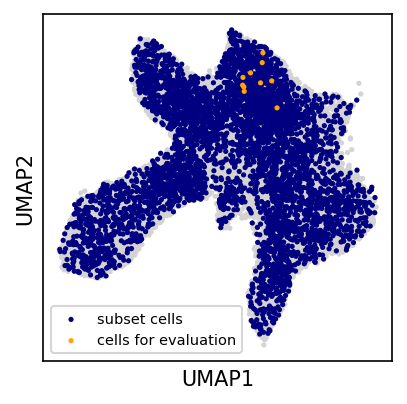

In [194]:
fig = plt.figure(figsize=(3,3), dpi=150)
ax = fig.gca()

sc.pl.umap(t7_ad, return_fig=False, show=False, ax=ax, size=25)
sc.pl.umap(subset_ad, na_color='navy', return_fig=False, show=False, ax=ax, size=25, label='subset cells')
sc.pl.umap(sampled_ad, na_color='orange', return_fig=False, show=False, ax=ax, size=25, label='cells for evaluation')

ax.legend(fontsize=7)

# ODE solve

In [212]:
device = mlp_model.device

def ode(t, s):

    t_in = torch.full((s.shape[0],1), t*15).float().to(device)
    
    dsdt = mlp_model.v(s.to(device), t_in)

    return dsdt * 1e-3

set up eval time list and initial condition

In [196]:
timepoints

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [197]:
# t_list
t_list = t7_ad.uns['pop']['t'][:n_timepoint] / 15

print(timepoints[:n_timepoint])
print(t_list)

[  3   7  12  27  49  76 112]
[0.2        0.46666667 0.8        1.8        3.26666667 5.06666667
 7.46666667]


In [198]:
s0 = sampled_ad.obsm['DM_EigenVectors'][:,:n_dimension]
s0 = torch.from_numpy(s0).float().to(device)

In [199]:

# configure training options
options = {}
options.update({'method': 'Dopri5'})
options.update({'h': None})
options.update({'t0': 0.2})
options.update({'t1': 7.5})
options.update({'rtol': 1e-7})
options.update({'atol': 1e-8})
options.update({'print_neval': False})
options.update({'neval_max': 1000000})
options.update({'safety': None})
options.update({'t_eval':t_list})
options.update({'interpolation_method':'cubic'})
options.update({'regenerate_graph':False})

In [213]:
s_int = odesolve(ode, s0, options = options) 

In [214]:
s_int = s_int.detach().cpu().numpy()

# visulize by the most correlated cells

In [215]:
from tqdm.contrib import concurrent
from scipy.stats import pearsonr

In [216]:
subset_cellstate = subset_ad.obsm['DM_EigenVectors'][:, :n_dimension]

def find_index(ode_out):
    r = [pearsonr(ode_out, dm)[0] for dm in subset_cellstate]
    indx = subset_ad.obs_names[np.argmax(r)]
    return indx

In [217]:
sout_time = np.stack([[t]*len(sampled_cbs) for t in timepoints[:n_timepoint]]).flatten()
matched_cbs = concurrent.process_map(find_index, s_int.reshape(-1,10), max_workers=20, chunksize=2)

matched_cbs = pd.DataFrame({'cb':matched_cbs, 'time':sout_time})

  0%|          | 0/70 [00:00<?, ?it/s]

In [218]:
matched_cbs.head()

,cb,time
0,7w11w_SITTD3_GTTAGTGGTTTCGACA-1-10x,3
1,7w11w_SITTC3_GTTTGGAGTTCGTACA-1-10x,3
2,7w11w_SITTC3_AAACGAACAGCATTGT-1-10x,3
3,2w4w_SITTD4_TTCCTAACATCCCGTT-1-10x,3
4,7w11w_SITTD3_AGCGATTAGGTAGACC-1-10x,3


## visualize

In [219]:
from matplotlib import cm

In [220]:
orange_colorlist = cm.get_cmap('Oranges', 7)

In [221]:
orange_colorlist(6)

(0.4980392156862745, 0.15294117647058825, 0.01568627450980392, 1.0)

In [222]:
coords_ls = []
for i,t in enumerate(timepoints[:n_timepoint]):
    cb_t = matched_cbs.query("`time` == @t").cb.tolist()

    coords_ls.append(subset_ad[cb_t].obsm['X_umap'])

coords_ls = np.stack(coords_ls) # 7, 20, 2

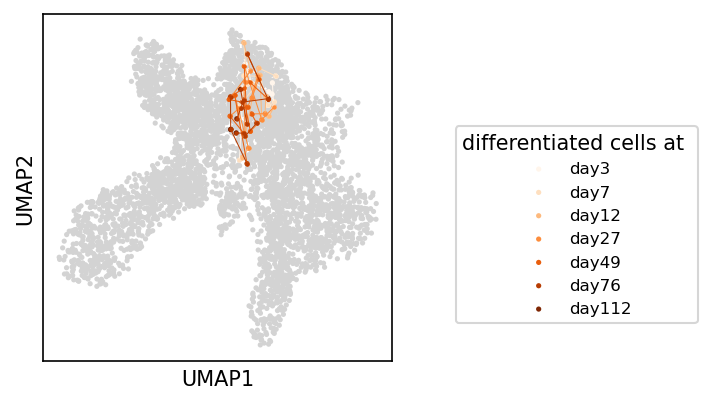

In [223]:
fig = plt.figure(figsize=(3,3), dpi=150)
ax = fig.gca()

sc.pl.umap(subset_ad, return_fig=False, show=False, ax=ax, size=25)

for t in range(6):
    for i in range(10):
        ax.plot(coords_ls[t:t+2, i, 0], coords_ls[t:t+2, i, 1], color=orange_colorlist(t), marker='o', markersize=1, linewidth=0.5)

for i,t in enumerate(timepoints[:n_timepoint]):
    cb_t = matched_cbs.query("`time` == @t").cb.tolist()

    sc.pl.umap(subset_ad[cb_t], na_color=orange_colorlist(i), return_fig=False, show=False, ax=ax, size=25, label=f'day{t}')

ax.legend(bbox_to_anchor=[0.9,0.2,1,0.5], fontsize=8, title="differentiated cells at ")

# visualize with scVelo

In [40]:
from anndata import AnnData
import scvelo as scv

In [66]:
# obs
sout_cbs = sum([[f"{cb}_t{t}" for cb in sampled_cbs] for t in timepoints[:n_timepoint]], [])
sout_time = np.stack([[t]*20 for t in timepoints[:n_timepoint]]).flatten()
sout_cbs = pd.DataFrame({'cb':sout_cbs, 'time': sout_time}).set_index("cb")

# var
var = pd.DataFrame([f'DM_{i}' for i in range(n_dimension)], columns=['Feature']).set_index("Feature")

# construct adata
sout_ad = AnnData(X = s_int.reshape(-1,10), obs=sout_cbs, var=var)
sout_ad.layers['ode_s'] = s_int.reshape(-1,10)

sout_ad

AnnData object with n_obs × n_vars = 140 × 10
    obs: 'time'
    layers: 'ode_s'

In [187]:
sc.tl.pca(sout_ad)

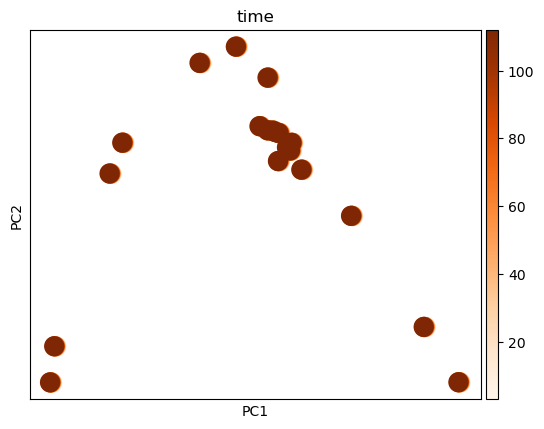

In [188]:
sc.pl.pca(sout_ad, color=['time'], cmap='Oranges')